<h1>1. Import Libraries</h1>

In [126]:
import h5py
import csv
import os
import sys
import tqdm
from matplotlib.colors import ListedColormap, to_rgb

import random
import numpy as np
import pandas as pd

import cv2
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

################## For training task ##################
import torch
import torchvision
import torch.nn as nn
from torch import Tensor
import torch.nn.functional as F

################## For Data task ##################
from torch.utils.data import DataLoader
from torchvision import transforms
import albumentations as A
from torchvision.transforms import InterpolationMode
from albumentations.pytorch import ToTensorV2

################## Import UNet from models ##################
PROJECT_DIR = '/kaggle/input/datasets/azurebob2/cityscapesegmentation/CityScapeSegmentation'
sys.path.insert(0, PROJECT_DIR)
from models import load_UNet, load_LightSeg

configs = {
    "project_name": "Multi task learning for Tumor Classification & Segmentation",
    "cityscape_path": '/kaggle/input/datasets/azurebob2/cityscapesegmentation/data',
    "cls_classes": 19,
    "image_size": 224,
    "n_channels": 3,
    # "weight_saved_path":"/users/PGS0404/atran16/Desktop/CityScapeSegmentation/trained_results/UNet_results/UNet_Cityscapes.pt",
    "weight_saved_path":"/users/PGS0404/atran16/Desktop/CityScapeSegmentation/trained_results/UNet_CBAM_results/UNet_CBAM_Cityscapes.pt",
    #"weight_saved_path" : "/users/PGS0404/atran16/Desktop/CityScapeSegmentation/trained_results_30K/UNet_results/UNet_Cityscapes.pt"
}

test_tf = A.Compose(
    [
        A.Resize(configs["image_size"], configs["image_size"]),
        #A.Normalize(mean=dataset_mean, std=dataset_std),
        ToTensorV2()
    ],
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

classes = {0: "road", 1: "sidewalk", 2: "building", 3: "wall", 4: "fence", 5: "pole", 
        6: "traffic light", 7: "traffic sign", 8: "vegetation", 9: "terrain", 10: "sky", 11: "person", 
        12: "rider", 13: "car", 14: "truck", 15: "bus", 16: "train", 17: "motorcycle", 18: "bicycle", 19: "others"}

color_mapping = {
    #Flat surfaces
    "road": "#666666", "sidewalk": "#282828",
    #Construction
    "building": "#FF3232", "wall" : "#6a329f", "fence": "#F110A6",
    #Objects / infrastructure
    "pole": "#523415", "traffic light": "#FFFF66", "traffic sign": "#FFFF00",
    #Nature
    "vegetation": "#008000", "terrain": "#6BAF6B",
    #Sky
    "sky": "#00b1ff",
    #Humans
    "person": "#E8BEAC", "rider": "#beace8",
    #Vehicle
    "car": "#FFA500", "truck": "#B07A15", "bus": "#101DCE", "train": "#3A2908", "motorcycle": "#E298D6", "bicycle": "#BEDFE5",
    #other:
    "others": "#E5ACB6"
}


colors = []
for i in sorted(classes.keys()):
    class_name = classes[i]
    colors.append(to_rgb(color_mapping[class_name]))

config_cmap = ListedColormap(colors)

<h1>2 Making segmentation</h1>

In [127]:
num_classes = configs['cls_classes'] + 1  # +1 for "others" class
trained_model = load_UNet(
    n_channels=configs['n_channels'],
    cls_classes=num_classes,
    pretrained_path=configs["weight_saved_path"],
    device=str(device),
    use_cbam=True
)
num_classes = configs['cls_classes'] + 1  # +1 for "others" class
# model = load_UNet(n_channels=configs['n_channels'], cls_classes=num_classes)

print(f"Model: UNet  |  Parameters: {sum(p.numel() for p in trained_model.parameters()):,}")
trained_model.to(device)
trained_model.eval()
print(f"trained weight loading successfully on device: {device}!")

CBAM Activated!
Loaded weights from '/users/PGS0404/atran16/Desktop/CityScapeSegmentation/trained_results/UNet_CBAM_results/UNet_CBAM_Cityscapes.pt'
Model: UNet  |  Parameters: 31,055,802
trained weight loading successfully on device: cpu!


In [128]:
def makePredict(trained_model, img_path):
    trained_model.eval()
    
    with torch.no_grad():
        
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    
        transformed = test_tf(image=image)
        transformed_image = transformed["image"].unsqueeze(0).to(device)
    
        output = trained_model(transformed_image)   # (1, C, H, W)
    
        # prediction
        pred_mask = torch.argmax(output, dim=1)     # (1, H, W)
        
        return pred_mask.to(device)

In [ ]:
img_path = '/users/PGS0404/atran16/Desktop/CityScapeSegmentation/data/visualization/2863.png'
#img_path = "/users/PGS0404/atran16/Desktop/CityScapeSegmentation/data/visualization/2798.png"

#img_path = "/users/PGS0404/atran16/Desktop/CityScapeSegmentation/data/visualization/2948.png"
#img_path = "/users/PGS0404/atran16/Desktop/CityScapeSegmentation/data/visualization/2671.png"

pred_mask = makePredict(trained_model, img_path)

<h1>6.3 Visualizing testing images</h1>

In [146]:
def segmented_mask_visualize(img_path, mask):
    plt.figure(figsize=(12, 6)) 
        
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    
    transformed = test_tf(image=image)
    transformed_image = transformed["image"].to(device)
    
    # Plot original image
    plt.subplot(1, 2, 1)
    plt.title("Image")
    plt.imshow(transformed_image.permute(1,2,0))
    plt.axis("off")
    
    
    # Plot prediction
    plt.subplot(1, 2, 2)
    plt.title(f"Segmented mask")
    plt.imshow(mask.squeeze(0), cmap=config_cmap, vmin=0, vmax=19)
    plt.axis("off")
    
    plt.tight_layout()
    plt.show()

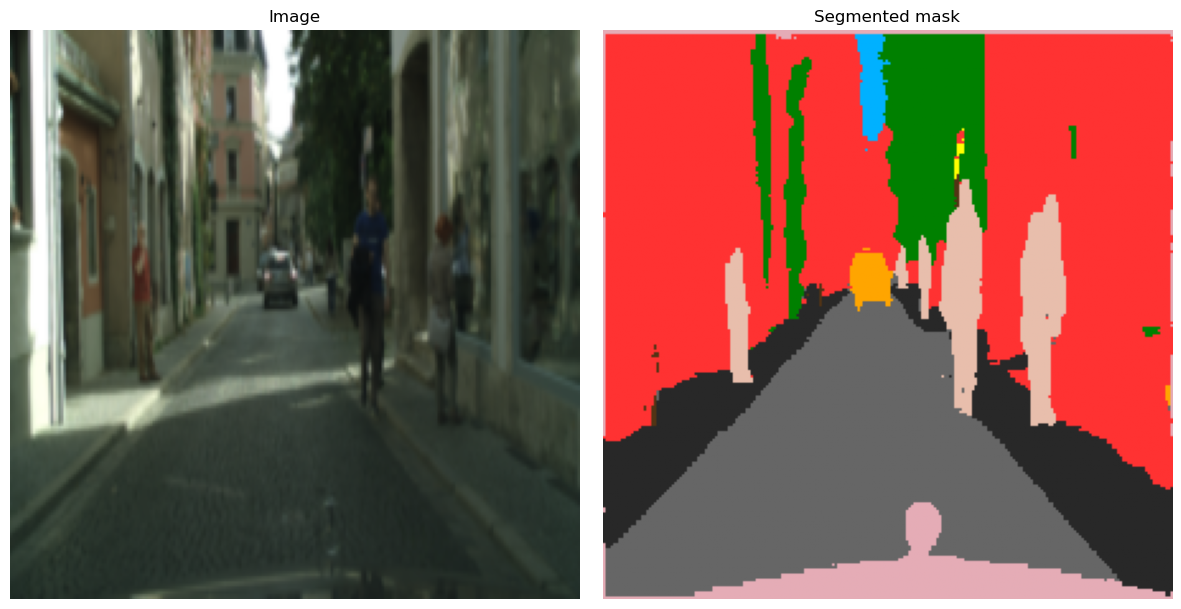

In [147]:
segmented_mask_visualize(img_path = img_path, mask = pred_mask)

In [ ]:
from scipy import ndimage

def count_objects(pred_mask, class_ids=[13], min_area=50):
    """Count separate objects of a given class in the predicted mask.
    Default class_id=13 is 'car'. Ignores regions smaller than min_area pixels."""
    for class_id in class_ids:
        mask = (pred_mask.squeeze(0).cpu().numpy() == class_id).astype(np.uint8)
        labeled, num_objects = ndimage.label(mask)
        count = 0
        for i in range(1, num_objects + 1):
            if np.sum(labeled == i) >= min_area:
                count += 1
        print(f"Class '{classes[class_id]}' (id={class_id}): {count} object(s) found (min_area={min_area})")
    return count, labeled

num_cars, labeled_mask = count_objects(pred_mask, class_ids=[11, 13], min_area=25)

Class 'person' (id=11): 5 object(s) found 
Class 'car' (id=13): 1 object(s) found 
